
# Assignment 2 - Image Filtering

---

**Computer Vision Course (Prof. Bozek), University of Cologne, SoSe 2026**.
In this assignment, you will explore filtering techniques in both the spatial and frequency domains on natural images. These methods are commonly used for preprocessing, for example to remove noise or enhance image details. Filtering also forms the foundation of convolutional neural networks, which you will encounter later in the lecture and tutorials. It builds on Lecture 2 by Prof. Bozek.

Notes:
- Due on: 26/04/2026
- 50 points
- Upload the completed notebook, including all results and generated plots. The notebook must run without errors. Ensure that all cells have been executed so that the outputs are visible in the notebook, if needed, upload complementary files or pictures.

---

In [583]:
# some imports; make sure to install opencv-python (cv2), matplotlib and numpy
from pathlib import Path
import urllib.request

import cv2
import matplotlib.pyplot as plt
import numpy as np

def url2img(url: str) -> np.ndarray:
	"""Download an image from a URL and decode it into an OpenCV image array."""
	req = urllib.request.urlopen(url)
	arr = np.asarray(bytearray(req.read()), dtype=np.uint8)
	return cv2.imdecode(arr, -1)

## Part 1: Fundamentals (8 points)
In the lecture, cross-correlation has been introduced. We can implement it like this:

In [584]:
def cross_correlation(input: np.ndarray, kernel: np.ndarray) -> np.ndarray:
  """Compute the 2D cross-correlation between an input image and a kernel.
	Parameters:
		:param input: (np.ndarray) 2D input image.
		:param kernel: (np.ndarray) 2D filter kernel.
  Returns:
      :return: output image after cross-correlation (valid region only)."""
  output_height = input.shape[0] - kernel.shape[0] + 1
  output_width = input.shape[1] - kernel.shape[1] + 1
  output = np.zeros((output_height, output_width))
  for y in range(output_height):
    for x in range(output_width):
      output[y, x] = np.sum(input[y:y+kernel.shape[0], x:x+kernel.shape[1]] * kernel)

  return output

In [585]:
input_image = np.array([[1, 2, 3],
                       [4, 5, 6],
                       [7, 8, 9]])

kernel = np.array([[1, 0, 0],
                   [0, 1, 0],
                   [1, 0, 0]])

result = cross_correlation(input_image, kernel)
print(result)

[[13.]]


### Question 1.1 (2 points)
 Using the above implementation of `cross_correlation()`, extend the function below to support zero-padding. Do not change the overall structure of the function. Apply this function to `input_image` and `kernel` and comment on the dimensionality of the output.


In [586]:
def cross_correlation_with_padding(input : np.ndarray, kernel : np.ndarray) -> np.ndarray:
  # vars 

  input_height = input.shape[0]
  input_width = input.shape[1]

  kernel_height = kernel.shape[0]
  kernel_width = kernel.shape[1]

  output_height = input_height + kernel_height - 1
  output_width = input_width + kernel_width - 1


  # Calculate padding

  padding_top = kernel_height // 2 
  padding_bot = (kernel_height -1) // 2

  padding_left = kernel_width // 2
  padding_right = (kernel_width - 1 ) // 2
 

  # Apply zero-padding to the input data

  padded_input = np.zeros((output_height, output_width))

  for y in range(input_height):
    for x in range(input_width):

      padded_input[y + padding_top, x + padding_left] = input[y,x]


  # cross_correlation


  return cross_correlation(padded_input, kernel)

### Question 1.2 (1 point)
**Explain the purpose of cross-correlation in image processing and give practical examples of its use.**


Cross-correlation helps highlighting features of interest in the input image. For example the Kernel: 

[[-1, -1, -1],
 [ 0,  0,  0],
 [ 1,  1,  1]]

 would highlight horizontal lines. 


### Question 1.3 (1 point)
**What is the purpose of convolution in image processing, and where is it commonly used?**

Convolution is thw same as cross-correlation just that the kernel is rotated by 180°. Thus both are equivalent in what they can do. Thus this question is redundant given Question 1.2 

### Question 1.4 (1 point)
 What is the difference between the cross-correlation and the convolution?

 See Question 1.3


### Question 1.5 (2 points)
Provide an implementation of convolution by completing the function below. The implementation should use zero-padding (“same” output size). Do not change the overall structure of the function.

In [587]:


def convolution2d(input : np.ndarray, kernel : np.ndarray) -> np.ndarray:

  # vars 

  kernel_height = kernel.shape[0]
  kernel_width = kernel.shape[1]

  if (kernel_height != kernel_width):
    print("Warning: kernel not square.")

  # Calculate padding

  
  #convolution code

  # rotate kernel, then apply cross-correlation_with_padding with rotated kernel

  rotated_kernel = np.zeros(kernel.shape)

  for y in range(kernel.shape[0]):
    for x in range(kernel.shape[1]):
      rotated_kernel[x,y] = kernel[kernel_height - 1 - y, kernel_width - 1 - x]

  return cross_correlation_with_padding(input,rotated_kernel)


### Question 1.6 (1 point)
Apply both cross-correlation and convolution to the same input matrix using two different kernels:

1.	one kernel for which both operations produce the same result,
2. one kernel for which the results are different.

Explain why this happens in each case.

cc k1 and conv k1 do the same because kernel_same is of the shape: 
[a b c]
[d e d]
[c b a]
In cc k2 and conv k2 we see different results because basically there is a cross correlation with two different kernels happening.


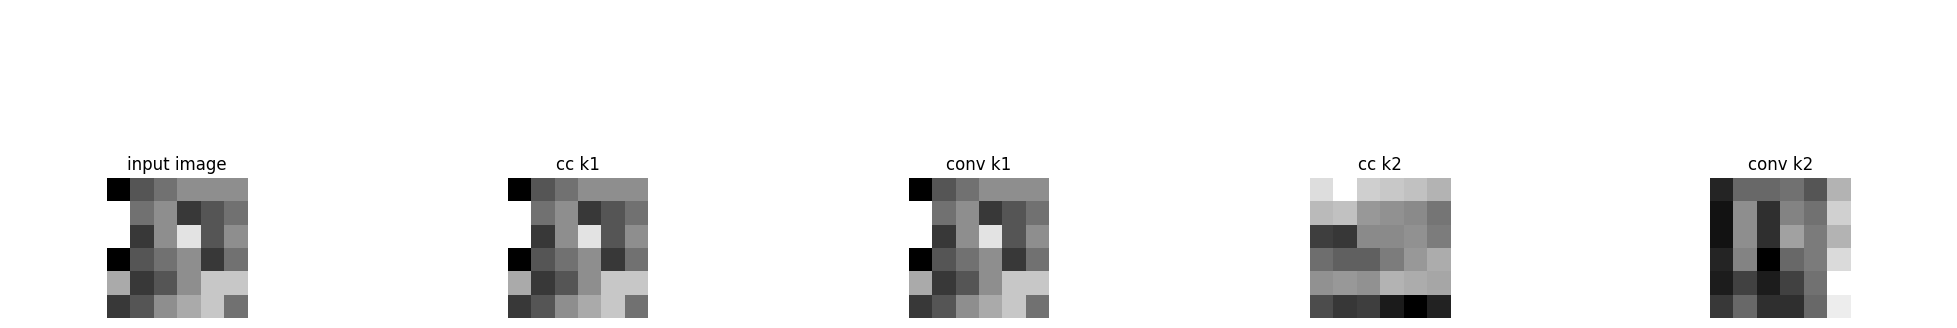

In [588]:
def export_as_grayscale(data):
    # Display the image inline in Jupyter
    plt.imshow(data, cmap='gray')
    plt.axis('off') # Hides the axes/numbers for a clean look
    plt.show()

def display_side_by_side(images, titles, *, histogram: bool = False, main_title = None):

    # default values 
    n_rows = 1
    n_images = len(images)

    # setup additional features
    if histogram:
        n_rows = 2

    # Create a figure and a set of subplots. 
    # n_rows, and 'len(images)' columns. figsize stretches it out horizontally.
    fig, axes = plt.subplots(n_rows + 1, len(images), figsize=(5 * n_images, n_rows * 4))
    
    axes = np.array(axes).reshape(n_rows + 1, n_images) # reshape for case n_rows == 1

    # Main Title Row

    if main_title:
        title = main_title
        ax_img = axes[0][1]
        ax_img.set_title(title)
        
    for i in range (n_images):
        ax_img = axes[0][i]
        ax_img.axis('off')

    # FIRST ROW
        
    for i in range(n_images):
        # set vars
        img = images[i]
        title = titles[i]

        ax_img = axes[1][i]

        # plot magic
        ax_img.imshow(img, cmap='gray')
        ax_img.set_title(title)
        ax_img.axis('off') # Hide the grid numbers



    # SECOND ROW

    if histogram:

        for i in range(n_images):
            # vars
            img = images[i]
            ax_hist = axes[2][i]

            # plot magic 
            ax_hist.hist(img.ravel(), bins=256, range=[0, 256], color='gray', alpha=0.7)
            ax_hist.set_xlim([0, 256])
        
        plt.tight_layout() # Ensures titles don't overlap
        plt.show()

# your code here
kernel_different = np.array(

[[-1, -1, -1],
 [ 0,  0,  0],
 [ 1,  1,  1]]
 
 )

kernel_same = np.array(

[[0,0,0],
 [0,1,0],
 [0,0,0]
]

)


image_test = np.array(

[[0,3,4,5,5,5],
 [9,4,5,2,3,4],
 [9,2,5,8,3,5],
 [0,3,4,5,2,4],
 [6,2,3,5,7,7],
 [2,3,5,6,7,4]
]

)

image_cc_k2 = cross_correlation_with_padding(image_test,kernel_different)

image_cc_k1 = cross_correlation_with_padding(image_test,kernel_same)

image_conv_k2 = convolution2d(image_test,kernel_different)

image_conv_k1 = convolution2d(image_test,kernel_same)

if (np.array_equal(image_cc_k2,image_conv_k2)): 
    print("Processes images '==' but shouldnt!")

if (not np.array_equal(image_cc_k1, image_conv_k1)):
    print("Processed image '!=' but should.")


display_side_by_side([image_test, image_cc_k1, image_conv_k1, image_cc_k2, image_conv_k2], ["input image", "cc k1", "conv k1", "cc k2", "conv k2"])

print("cc k1 and conv k1 do the same because kernel_same is of the shape: \n" \
"[a b c]\n" \
"[d e d]\n" \
"[c b a]\n" \
"In cc k2 and conv k2 we see different results because basically there is a cross correlation with two different kernels happening."\
    )

#print("Kernel input: ")
#export_as_grayscale(image_test)

#print("Kerner 'different': ")
#export_as_grayscale(image_cc_k2)
#export_as_grayscale(image_conv_k2)

#print("kernel 'same': ")
#export_as_grayscale(image_cc_k1)
#export_as_grayscale(image_conv_k1)

## Part 2: Spatial Filtering (20 points)
In this part, we will explore filtering operations in the spatial domain by applying different kernels to images. You will observe how these filters affect image properties and can be used for different objectives.

### 2.1: Noise Simulation

Before we apply any filters, we want to define a way to evaluate the effectiveness of filtering techniques. One way is to first simulate noisy conditions by adding noise to an image. This allows us to assess how well each filter reduces unwanted disturbances while preserving important image details.

**Noise types we will simulate**

- **Gaussian Noise:**

  - *Description:* Continuous noise following a normal distribution with values centered around a mean.

  - *Purpose:* Affects all pixels, making it useful for testing how well filters smooth distributed noise while preserving image structure.

- **Salt-and-Pepper Noise:**

  - *Description:* Random black and white pixels that create a speckled appearance.

  - *Purpose:* Introduces strong, isolated outliers, testing whether filters can remove extreme values without blurring surrounding regions.

Below is a function that let's us add both noise types to an image at different intensities:

In [589]:
def apply_noise(image: np.ndarray, *,  noise_type: str, intensity: float = .01, seed: int = 42) -> np.ndarray:
    """Adds salt-and-pepper or gaussian noise to a grayscale image.
    Parameters:
        :param image: (np.ndarray) grayscale image of shape (x, y).
        :param noise_type: (str) type of noise to be applied. Can be 'salt_pepper' or 'gaussian'.
        :param intensity: (float) noise intensity. For 'salt_pepper', it is the percentage of pixels to be changed.
                 For 'gaussian', it scales the variance of the noise.
        :param seed: (int) random seed.
	Returns:
        :return: (np.ndarray) noisy grayscale image with the specified noise applied, same shape as input."""
    row, col = image.shape
    out = np.copy(image)
    rng = np.random.default_rng(seed)

    if noise_type == 'salt_pepper':
        # calculate number of salt and pepper pixels
        num_salt = num_pepper = int(np.ceil(intensity * image.size * .5)) # symmetric, i.e. same amount of salt vs pepper pixels

        # generate salt noise
        salt_coords = (rng.integers(0, row, num_salt), rng.integers(0, col, num_salt))  # choose random pixels
        out[salt_coords] = [255]  # set them to [255, 255, 255] (white)

        # generate pepper noise (set pixels to [0, 0, 0] (black) for all channels)
        pepper_coords = (rng.integers(0, row, num_pepper), rng.integers(0, col, num_pepper))  # choose random pixels, allow potential overlap with salt pixels but effect is small and we don't mind
        out[pepper_coords] = [0]  # set them to [0, 0, 0] (black)

    elif noise_type == 'gaussian':

        mean, var = 0, intensity  # chose zero mean and variance based on intensity
        sigma = var ** .5
        gauss = rng.normal(mean, sigma, (row, col))

        # add Gaussian noise to the image and clip to valid range
        out = image + gauss * 255
        out = np.clip(out, 0, 255).astype(np.uint8)  # ensure values are within valid range for display

    else:
        raise ValueError("Invalid noise type. Please use 'salt_pepper' or 'gaussian'.")

    return out

### Question 2.1.1 (5 points)
 Use the function `apply_noise()` to apply both types of noise on the image of crush below. You can test different intensities of noise. Display the original image and the two noisy images with their respective histogram (3 points). Describe the impact of the noise on the histograms (2 points).



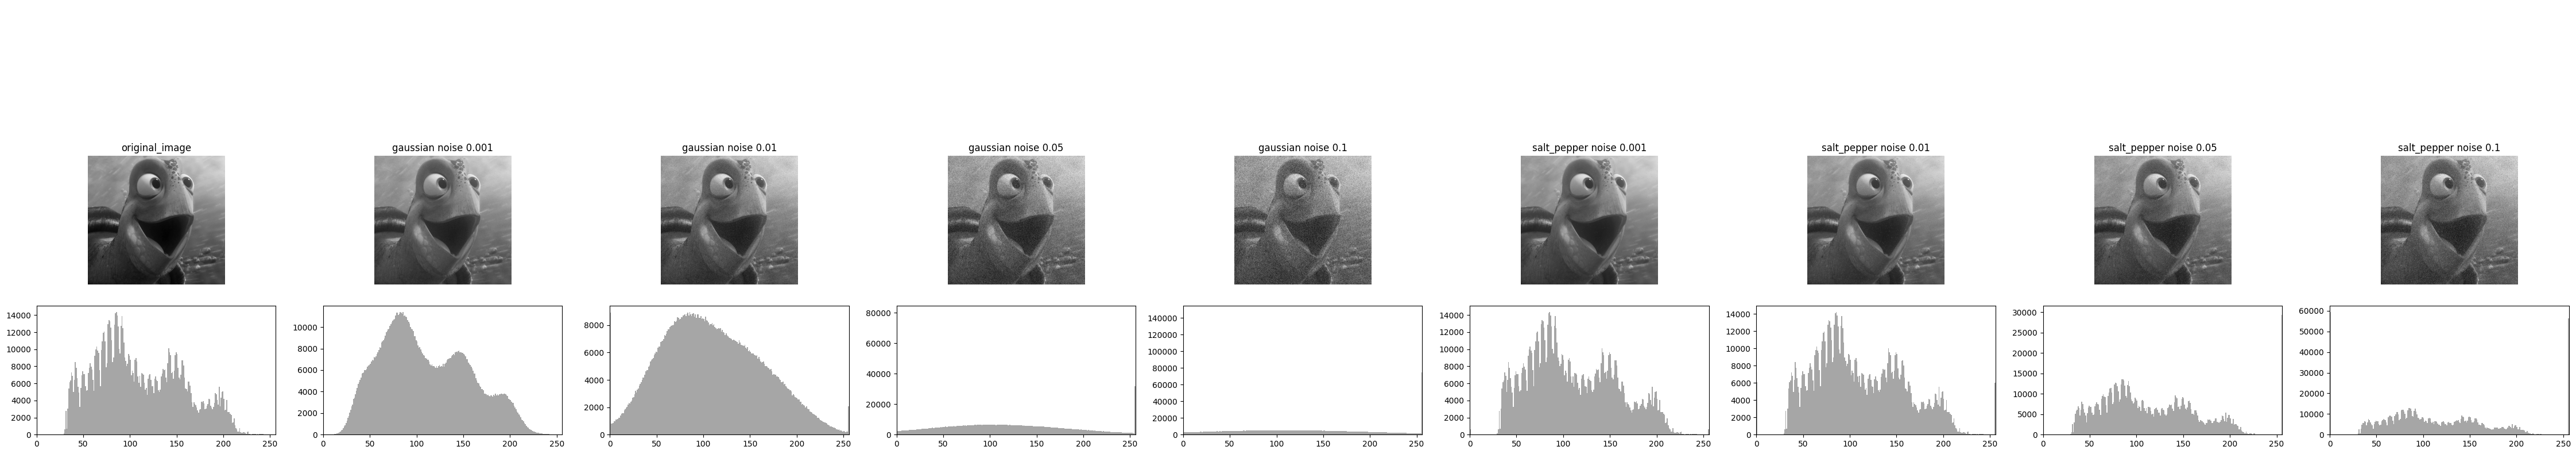

Gaussian: spikes in the histogram disappear. for high intensity edge-values accumulate. 
Salt Pepper: Spikes remain, edge values accumulate 
 


In [590]:
crush_original = cv2.cvtColor(url2img("https://github.com/bozeklab/ComputerVision_SS24/blob/main/resources/assignment_2/crush.png?raw=true"), cv2.COLOR_BGR2GRAY)



# your code here


gaussian_image_z = apply_noise(crush_original, noise_type = "gaussian", intensity = 0.001)

salt_pepper_img_z = apply_noise(crush_original, noise_type = "salt_pepper", intensity = 0.001)


gaussian_image_a = apply_noise(crush_original, noise_type = "gaussian", intensity = 0.01)

salt_pepper_img_a = apply_noise(crush_original, noise_type = "salt_pepper", intensity = 0.01)

gaussian_image_b = apply_noise(crush_original, noise_type = "gaussian", intensity = 0.05)

salt_pepper_img_b = apply_noise(crush_original, noise_type = "salt_pepper", intensity = 0.05)


gaussian_image_c = apply_noise(crush_original, noise_type = "gaussian", intensity = 0.1)

salt_pepper_img_c = apply_noise(crush_original, noise_type = "salt_pepper", intensity = 0.1)

display_side_by_side([crush_original, 
                      gaussian_image_z,
                      gaussian_image_a,
                      gaussian_image_b,
                      gaussian_image_c, 
                      salt_pepper_img_z,
                      salt_pepper_img_a, 
                      salt_pepper_img_b, 
                      salt_pepper_img_c], 
                      ["original_image",
                       "gaussian noise 0.001",
                       "gaussian noise 0.01",
                       "gaussian noise 0.05", 
                       "gaussian noise 0.1",  
                       "salt_pepper noise 0.001",                   
                       "salt_pepper noise 0.01",
                       "salt_pepper noise 0.05",
                       "salt_pepper noise 0.1"], 
                       histogram = True)


print("Gaussian: spikes in the histogram disappear. for high intensity edge-values accumulate. \n" \
"Salt Pepper: Spikes remain, edge values accumulate \n ")

### Question 2.1.2 (2 points)
We can also quantitatively measure the impact of the noise using the mean squared error between the original image and the noisy one.

The mean-squared error is defined as:

$MSE = \frac{1}{n}\sum_{i=1}^n (I_i - \hat{I}_i)^2$, where
- $n$ is the total number of pixels
- $I(i)$ and $\hat{I}(i)$ are the intensity values of pixel $i$ in the original and output images.

Implement a function to calculate the `mse` and print the resulting values between the original and the two noisy images. Use intensity values of `0.01` for salt-and-pepper noise and `0.1` for Gaussian noise.

In [591]:

def mse(img1: np.ndarray, img2: np.ndarray) -> float:
    # vars: 
    height = img1.shape[0]
    width = img1.shape[1]
    total_error = 0.0
       
    # errors
    if height != img2.shape[0] or width != img2.shape[1]:
        print("Error: Dimensions of arrays dont match.")


    # calculations
    for y in range(height):
        for x in range(width):
            total_error = total_error + (int(img1[y, x]) - int(img2[y, x])) ** 2

    # mean 
    final_mse = total_error / (width * height)

    return float(final_mse)

In [592]:
print("MSE gaussian 0.1: ", mse(crush_original, gaussian_image_c))
print("MSE salt-pepper 0.01: ", mse(crush_original, salt_pepper_img_b))

MSE gaussian 0.1:  4731.1834162703235
MSE salt-pepper 0.01:  910.6199741949472


### 2.2: Spatial Low-pass Filters (14 points)

Low-pass filters allow low-frequency signals to pass while attenuating (reducing) high-frequency components. When applied to images, this results in smoothing, as fine details and noise are suppressed.

**Purpose of Low-Pass Filters in Computer Vision**

- **Noise Reduction:** Images often contain high-frequency noise due to sensor imperfections, environmental conditions, or compression artifacts. Low-pass filters reduce this noise, producing a cleaner image.

- **Smoothing:** By averaging pixel values over a local neighborhood, low-pass filters reduce sharp transitions and fine details, leading to a smoother appearance. This is commonly used as a preprocessing step for further analysis.

- **Downsampling:** Before reducing image resolution, low-pass filters are used to prevent aliasing—distortions that occur when high-frequency content is undersampled.

- **Edge Detection Preprocessing:** Smoothing an image before edge detection helps suppress irrelevant high-frequency variations, leading to more stable and accurate edge detection results.

Low-pass filters can be implemented either in the **spatial domain** (e.g., via convolution with a smoothing kernel such as a Gaussian filter) or in the **frequency domain** by attenuating high-frequency components.

### Question 2.2.1 (2 points)
In the lecture two types of spatial low-pass filters were introduced. Implement two functions to compute their respective kernels, given a desired kernel size. Use `numpy` functions only.

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.02777778 0.02777778 0.02777778 0.02777778
  0.02777778 0.02777778 0.         0.        ]
 [0.         0.         0.02777778 0.02777778 0.02777778 0.02777778
  0.02777778 0.02777778 0.         0.        ]
 [0.         0.         0.02777778 0.02777778 0.02777778 0.02777778
  0.02777778 0.02777778 0.         0.        ]
 [0.         0.         0.02777778 0.02777778 0.02777778 0.02777778
  0.02777778 0.02777778 0.         0.        ]
 [0.         0.         0.02777778 0.02777778 0.02777778 0.02777778
  0.02777778 0.02777778 0.         0.        ]
 [0.         0.         0.02777778 0.02777778 0.02777778 0.02777778
  0.02777778 0.02777778 0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0

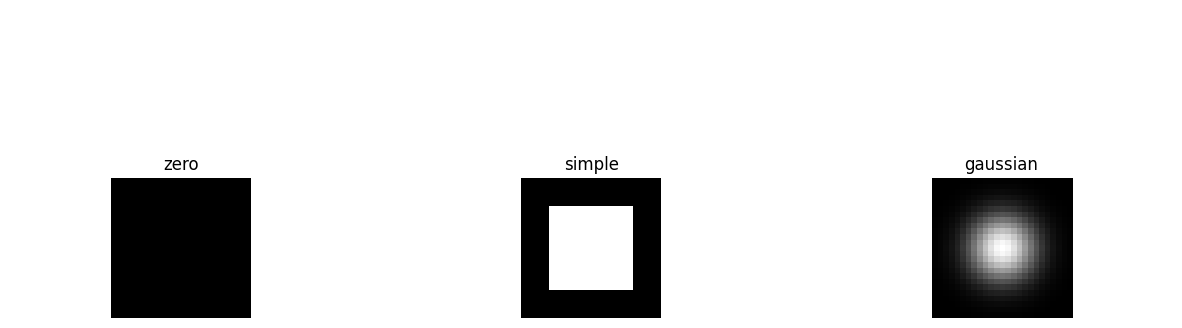

In [593]:
def simple_kernel(kernel_size: np.uint(8),* , edge_size = -1) -> np.ndarray: # you can rename the function and add other parameters if needed
  #code

  if edge_size == -1:
    edge_size = kernel_size // 4
  
  #print("edge size", edge_size)

  output = np.zeros([kernel_size, kernel_size])

  norm_factor = (kernel_size - 2 * edge_size) ** 2

  for y in range(kernel_size):
    if y >= edge_size:
      if y < kernel_size - edge_size:
        for x in range(kernel_size):
          if x >= edge_size:
            if x < kernel_size - edge_size:
              output[x,y] = 1 / norm_factor

  #print(output)

  return output

def gaussian_kernel(kernel_size: np.uint(8),* , sigma = 1) -> np.ndarray: # you can rename the function and add other parameters if needed
  #code
  
  output = np.zeros([kernel_size, kernel_size])

  for y in range(kernel_size):
    for x in range(kernel_size):
      # normalize x, y
      x_prime = x - kernel_size // 2
      y_prime = y - kernel_size // 2

      output[x,y] = (1 / (2 * np.pi * (sigma ** 2))) * np.exp( - (x_prime**2 + y_prime**2) / (2 * (sigma ** 2)))


  return output

s = simple_kernel(10)
g = gaussian_kernel(25, sigma = 4)
z = np.zeros([25,25])

display_side_by_side([z,s,g], ["zero","simple", "gaussian"])

print(s)





### Question 2.2.2 (5 points)
Apply the two filters to the noisy (gaussian) image of crush (2 points). Use `convolution2d()` from *Question 1.5* (or `convolve2d()` from `scipy` if you did not solve the question).
For each filter, compute the `mse` between the convoluted/filtered image and the noisy image and compare it to the `mse` of the noise image vs. the original image without noise. Also display the convoluted/filtered images and their histograms (2 points). Comment on the differences between the two filtered images (1 point). In the process, try out different kernel sizes.

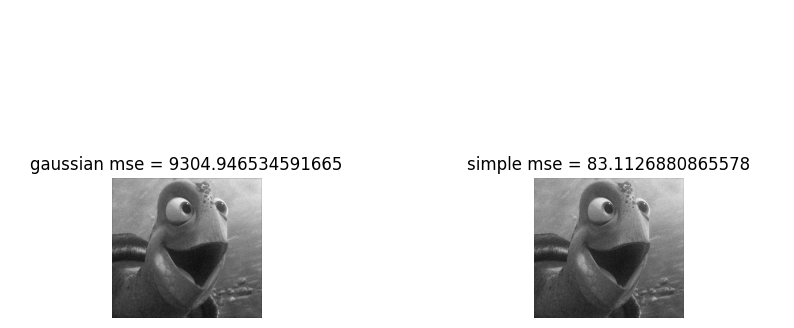

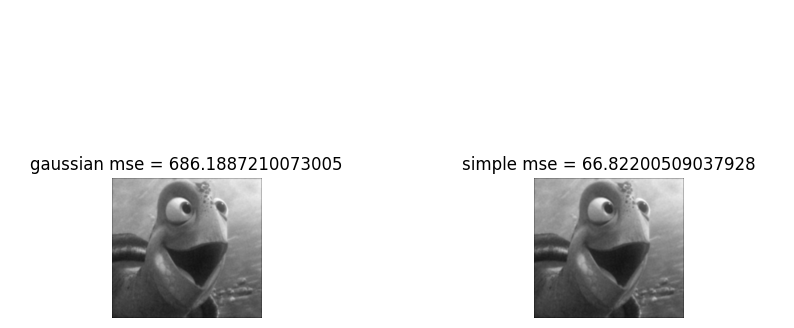

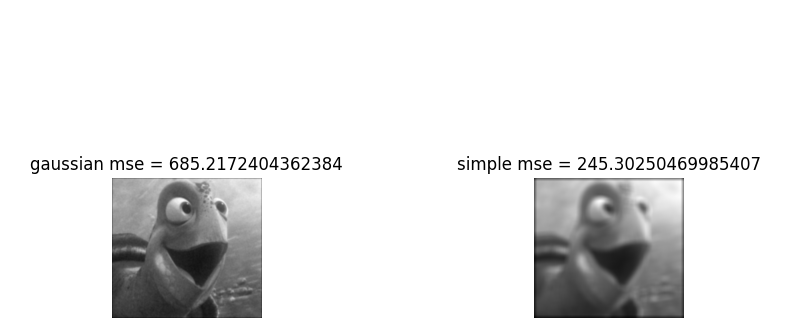

In [594]:
crush_noisy = apply_noise(crush_original, noise_type='gaussian', intensity=.01)



# your code here

for kernel_size in [5,25,95]:

    crush_noisy_gaussian = convolution2d(crush_noisy, gaussian_kernel(kernel_size, sigma = 4))
    crush_noisy_simple = convolution2d(crush_noisy, simple_kernel(kernel_size))

    mse_gausian = mse(crush_noisy, crush_noisy_gaussian)
    mse_simple = mse(crush_original, crush_noisy_simple)

    info_gaussian = f"gaussian mse = {mse_gausian}"
    info_simple = f"simple mse = {mse_simple}"

    display_side_by_side([crush_noisy_gaussian,crush_noisy_simple], [info_gaussian,info_simple])

### 2.3: Spatial High-pass Filters (6 points)
In contrast to low-pass filters, high-pass filters allow high-frequency components to pass through while attenuating (reducing) low-frequency parts. These filters are applied to images to enhance edges, fine details, and textures.

**Purpose of High-Pass Filters in Computer Vision:**

 - **Edge Detection:** High-pass filters are commonly used to highlight edges in images. Edges are areas with significant intensity changes, corresponding to high-frequency components. By enhancing these components, high-pass filters make the edges more pronounced.

 - **Detail Enhancement:** These filters can bring out fine details and textures in an image that might be otherwise overshadowed by broader, low-frequency components. This can be particularly useful in applications like medical imaging, where fine details are crucial.

- **Feature Extraction:** In many computer vision tasks, such as object recognition and image segmentation, identifying and analyzing features like edges and textures are critical. High-pass filters help in isolating these features from the background.

- **Image Sharpening:** High-pass filters can be used to sharpen images, making them appear clearer and more defined. This is often done by enhancing the high-frequency components that correspond to the fine details of the image.

### Question 2.3.1 (4 points)
In the lecture two types of spatial high-pass filters were introduced.
Define their kernels using `np.array()` and apply them to the sudoku grid image below using `convolution2d()` (or `convolve2d()`). Display the resulting images.

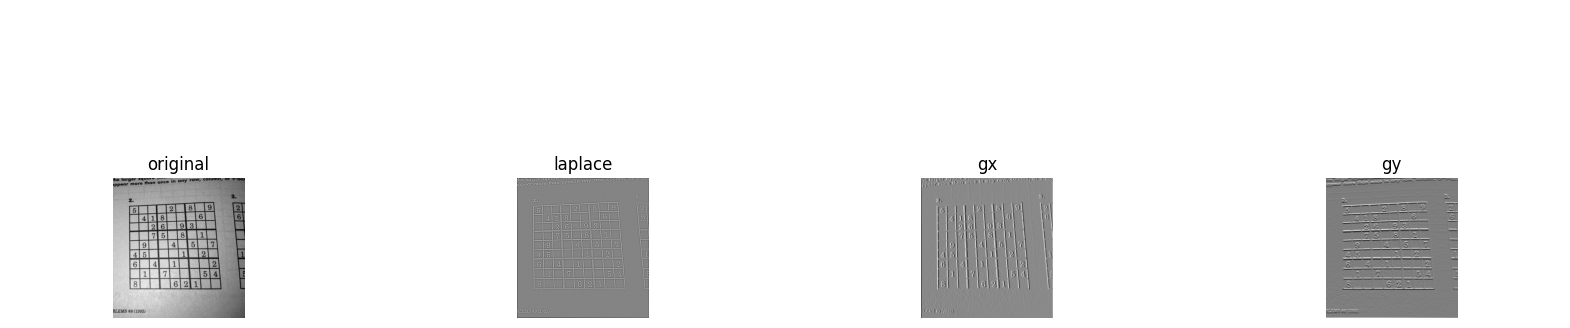

In [595]:
sudoku = cv2.cvtColor(url2img("https://github.com/bozeklab/ComputerVision_SS24/blob/main/resources/assignment_2/sudoku.png?raw=true"), cv2.COLOR_BGR2GRAY)

# kernel = np.array([...])

#def laplacian_kernel(size):
    
    
laplacian_kernel_small = np.array([[0,1,0],
                             [1,-4,1],
                             [0,1,0]])


gx_kernel_small = np.array([[-1,-2,-1],
                             [0,0,0],
                             [1,2,1]])

gy_kernel_small = np.array([[-1,0,1],
                             [-2,0,2],
                             [-1,0,1]])

laplace_sudoku = convolution2d(sudoku, laplacian_kernel_small)
gx_sudoku = convolution2d(sudoku, gx_kernel_small)
gy_sudoku = convolution2d(sudoku, gy_kernel_small)

gaussian_sudoku = convolution2d(sudoku, gaussian_kernel(25))
simple_sudoku = convolution2d(sudoku, simple_kernel(25))

display_side_by_side([sudoku, laplace_sudoku, gx_sudoku,gy_sudoku], ["original", "laplace", "gx", "gy"])


### Question 2.3.2 (2 points)
Which filter would you use to extract the horizontal lines or vertical lines of an image? Apply each procedure to the sudoku image and display the results.

In [596]:
# your code here
# I would choose the gx filter for the vertical lines and the gy filter for the horizontal lines see the images above.

## Part 3: Filtering in the Frequency Domain (20 points)

So far, we have been working with filters directly in the spatial domain, i.e. operating on pixel neighborhoods. In this part, we switch perspectives and look at images in the frequency domain.

To do this, we use the Fourier transform. In NumPy, `np.fft.fft2()` computes the 2D Fourier transform of an image and returns a complex-valued array. The first argument is the input image (grayscale). The second argument is optional and controls the output size: if it is larger than the input, the image is zero-padded before the transform; if it is smaller, the image is cropped. If omitted, the output has the same size as the input.

By default, the zero-frequency component (DC component) is located in the top-left corner of the result. For visualization and analysis, it is usually more convenient to shift it to the center using `np.fft.fftshift()`.

From the Fourier transform, you can compute the magnitude and phase spectra, which describe how much of each frequency is present and how these frequencies are aligned.

An example usage would be

```python
f = np.fft.fft2(img)  # complex array (a + i*b)
fshift = np.fft.fftshift(f)  # shift center to (0, 0)
magnitude_spectrum = np.log(np.abs(fshift))  # abs takes amplitude of complex array (sqrt(a**2 + b**2)), log for better separation/visualization
phase_spectrum = np.angle(fshift)  # phase: arctan(b /a)
```

### Question 3.1 (4 points)
Transform the 4 previously defined spatial filters into the frequency domain and visualize the results (3 points). Explain why 2 of them are 'low-pass' and the other two are 'high-pass' filters (1 point).

*Hint:* For a better result, define the size of the output as `np.fft.fft2(x, s = [25,25])` and use large kernel size.



I can actually not tell from the frequency domain why they are low or highpass filter but also i dont know if i generated the right images. 




/var/folders/k0/3d_9w1n13pb3ysfrt2m_77rm0000gn/T/ipykernel_34235/2255165977.py:7: RuntimeWarning: divide by zero encountered in log
  magnitude_spectrum = np.log(np.abs(fshift))  # abs takes amplitude of complex array (sqrt(a**2 + b**2)), log for better separation/visualization


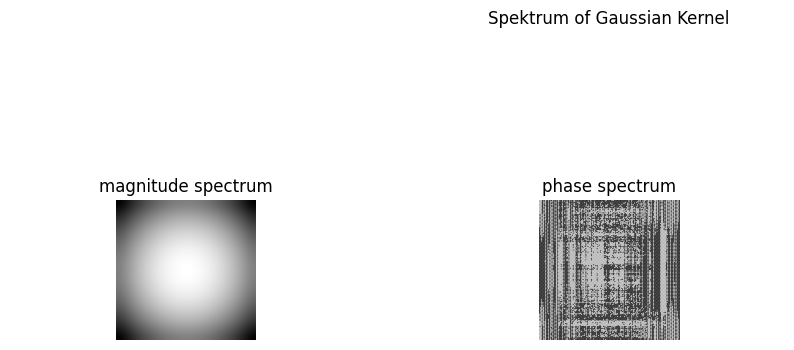

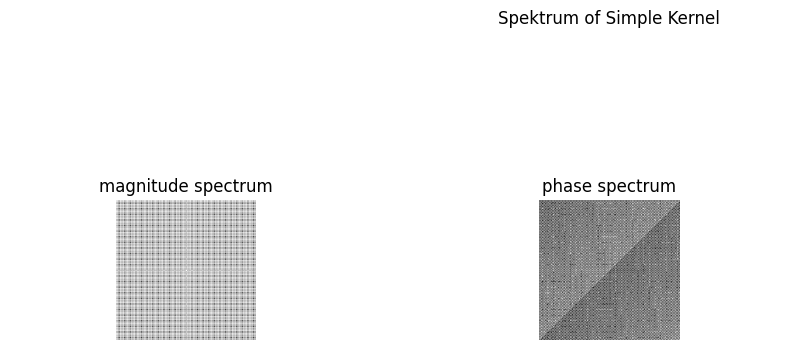

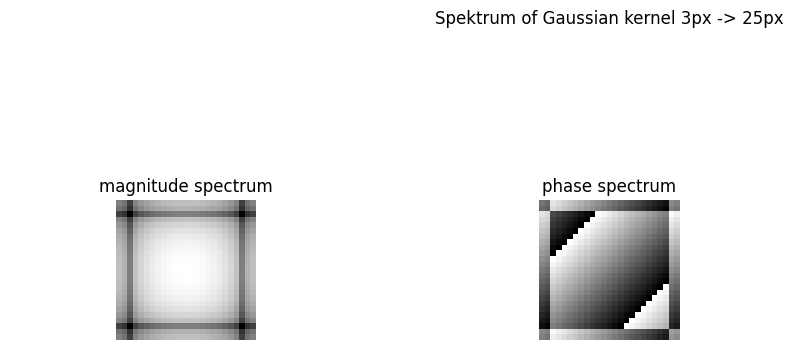

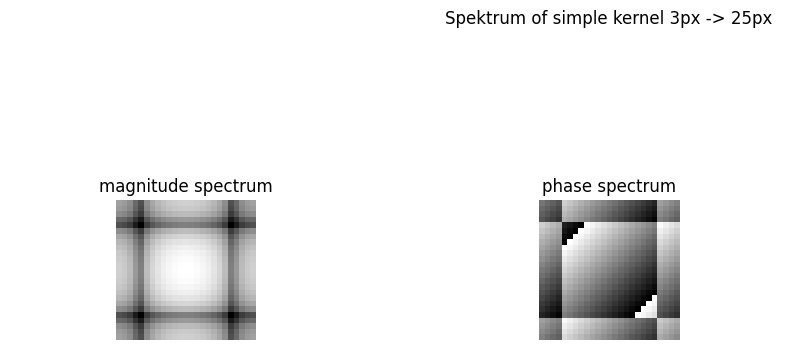

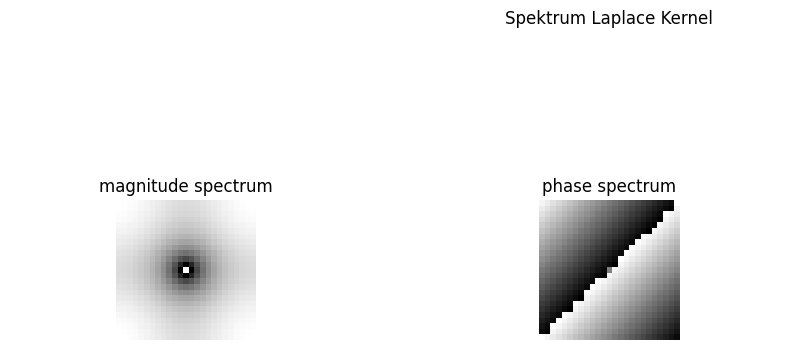

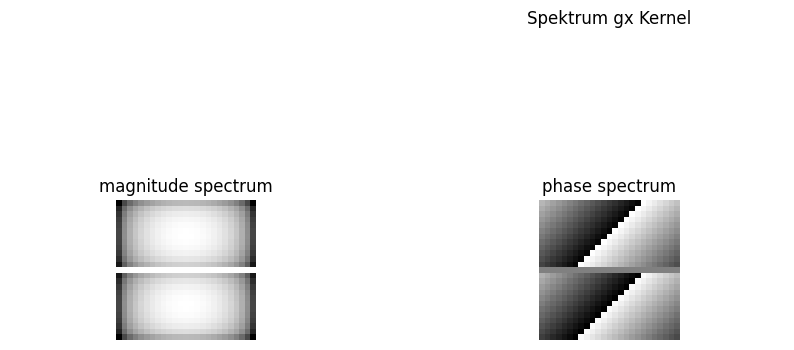

In [597]:
# your code here

def compute_spectrum(img, *, size = None):

    f = np.fft.fft2(img, size)  # complex array (a + i*b)
    fshift = np.fft.fftshift(f)  # shift center to (0, 0)
    magnitude_spectrum = np.log(np.abs(fshift))  # abs takes amplitude of complex array (sqrt(a**2 + b**2)), log for better separation/visualization
    phase_spectrum = np.angle(fshift)  # phase: arctan(b /a)
    
    return magnitude_spectrum, phase_spectrum

def magnitude(img):
    magnitude = np.log(np.abs(img))
    return magnitude

def phase(img):
    phase = np.angle(img)
    return phase

def display_spectrum(img, *, size = None, title = None):
    
    m, s = compute_spectrum(img, size = size)
    display_side_by_side([m,s], ["magnitude spectrum", "phase spectrum"], main_title = title)


print("\n" \
      "\n" \
"I can actually not tell from the frequency domain why they are low or highpass filter but also i dont know if i generated the right images. \n" \
"\n" \
"")

display_spectrum(gaussian_kernel(200), title = "Spektrum of Gaussian Kernel")

display_spectrum(simple_kernel(200), title = "Spektrum of Simple Kernel")

display_spectrum(gaussian_kernel(3), size = [25,25], title = "Spektrum of Gaussian kernel 3px -> 25px")

display_spectrum(simple_kernel(3), size = [25,25], title = "Spektrum of simple kernel 3px -> 25px")

display_spectrum(laplacian_kernel_small, size = [25,25],title = "Spektrum Laplace Kernel")

display_spectrum(gx_kernel_small, size = [25,25], title = "Spektrum gx Kernel")

#display_spectrum(laplace_sudoku, title = "Spektrum Laplace sudoku")

#display_spectrum(gx_sudoku, title = "Spektrum gx Filter sudoku")

#display_spectrum(gaussian_sudoku, title = "Spectrum gaussian sudoku")

#display_spectrum(simple_sudoku, title = "Spectrum simple filter sudoku")



### Question 3.2 (2 points)
How can we make use of the frequency domain transformation for low and high pass filtering? Define functions that implement the ideal low-pass and high-pass filters.

In [598]:
def ideal_low_pass_filter_mask(cutoff: float, image_shape: tuple[int, ...]) -> np.ndarray:
    # your code here

    n_y = image_shape[0]
    n_x = image_shape[1]

    output = np.zeros([n_y, n_x])

    for y in range(n_y):
        for x in range(n_x):
            D_y_x = ((x - n_x/2)**2 + (y - n_y/2)**2) ** 0.5
            if D_y_x < cutoff:
                output[y,x] = 1

    return output

def ideal_high_pass_filter_mask(cutoff: float, image_shape: tuple[int, ...]) -> np.ndarray:
    # your code here
    n_y = image_shape[0]
    n_x = image_shape[1]

    output = np.zeros([n_y, n_x])

    for y in range(n_y):
        for x in range(n_x):
            D_y_x = ((x - n_x/2)**2 + (y - n_y/2)**2) ** 0.5
            if D_y_x > cutoff:
                output[y,x] = 1

    return output

### Question 3.3 (6 points)

Use your ideal low-pass and high-pass filters and apply them to the `tshirt` image. Display the results of both filters in the spatial domain and in the frequency domain using the magnitude spectrum. (4 points)

Comment on the effect of each filter on the image. (2 points)

- *Hint 1:* For the inverse Fourier transform, you can use:

```python
f_ishift = np.fft.ifftshift(fshift)
img_back = np.fft.ifft2(f_ishift)
img_back = np.abs(img_back)
```

- *Hint 2:* To visualize the magnitude spectrum more clearly, it is often helpful to use a logarithmic transformation, for example `magnitude_spectrum = np.log(np.abs(fshift) + 1)`.

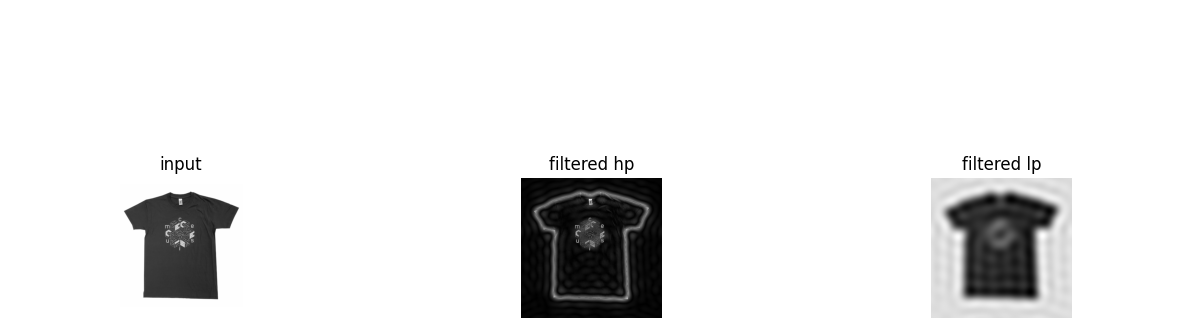

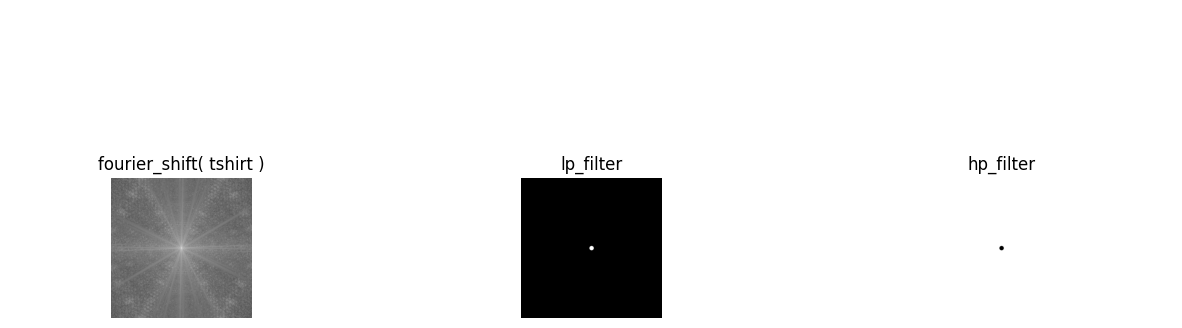

In [599]:
# load image and convert to grayscale
tshirt = cv2.cvtColor(url2img("https://github.com/bozeklab/ComputerVision_SS24/blob/main/resources/assignment_2/tshirt.png?raw=true"), cv2.COLOR_BGR2GRAY)

cutoff = 50

# create the ideal frequency masks
ideal_lp = ideal_low_pass_filter_mask(cutoff, tshirt.shape)
ideal_hp = ideal_high_pass_filter_mask(cutoff, tshirt.shape)

# apply the filters and display results
# your code here


def fourier_shift(img):
    
    output = np.fft.fft2(img)
    output = np.fft.fftshift(output) 

    return output

def i_fourier_shift(img):
    output = np.fft.ifftshift(img)
    output = np.fft.ifft2(output)
    output = np.abs(output)
    return output

# 0. define filter

shape = np.shape(tshirt)
cutoff = 10

lp_filter = ideal_low_pass_filter_mask(cutoff = cutoff, image_shape = shape)
hp_filter = ideal_high_pass_filter_mask(cutoff = cutoff, image_shape = shape)

# 1. Tshirt -> frequency domain , shift

f_tshirt = fourier_shift(tshirt)

# 2. apply filter - pointwise multiplication

f_tshirt_filtered_lp = f_tshirt * lp_filter
f_tshirt_filtered_hp = f_tshirt * hp_filter

# 3. filtered tshirt -> space domain

tshirt_filtered_hp = i_fourier_shift(f_tshirt_filtered_hp)
tshirt_filtered_lp = i_fourier_shift(f_tshirt_filtered_lp)




# plots
display_side_by_side([tshirt, tshirt_filtered_hp, tshirt_filtered_lp], ["input","filtered hp","filtered lp"])

display_side_by_side([magnitude(f_tshirt), lp_filter, hp_filter], ["fourier_shift( tshirt )", "lp_filter", "hp_filter"])

### Question 3.4 (8 points)
We have an image which has been corrupted by periodic noise. Is there a way we can restore the original image?

1. Transform the image into the frequency domain, display the magnitude spectrum and save it. (2 points)
2. Can you find something suspicious in the spectrum? Try to "fix" the spectrum. You can use any image editing software. (1 point)
3. Use the edited spectrum to restore the uncorrupted image. (5 points)

*Hint:* Remember to take the phase into account for the inverse transformation.

The number of white pixels is:  7


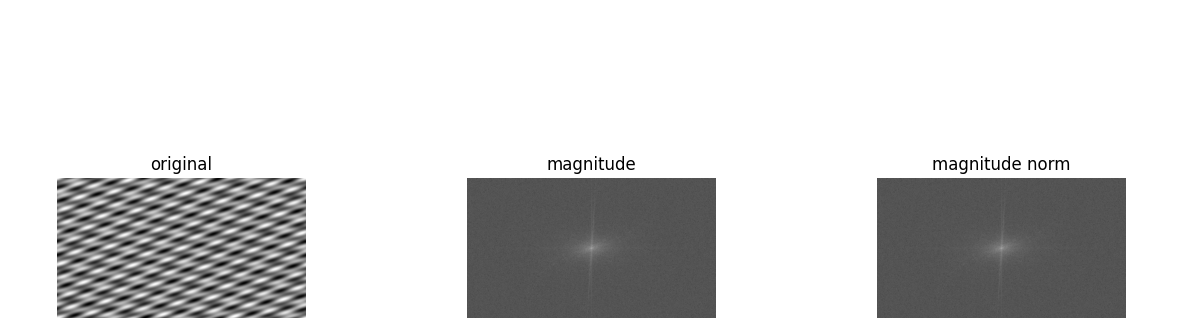

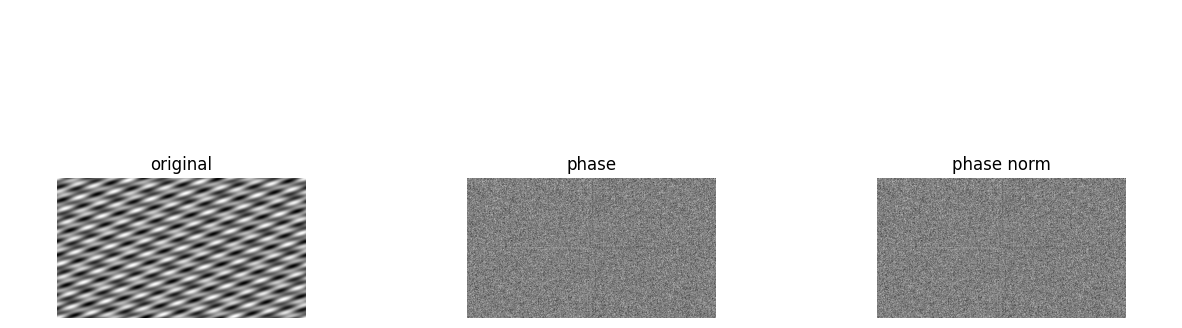

In [600]:
grayscale_img = cv2.cvtColor(url2img('https://github.com/bozeklab/ComputerVision_SS24/blob/main/resources/assignment_2/corrupted_img.png?raw=true'), cv2.COLOR_BGR2GRAY)
edited_spectrum_path = Path('./fft_spectrum_edit.png')

# Fourier transform
f_img = fourier_shift(grayscale_img)

magnitude_spectrum = magnitude(f_img)
phase_spectrum = phase(f_img)

# normalize the spectrum into [0,1] range and save it, cache the normalization constants (you'll need them later)
max_val_mag_spec = np.max(magnitude_spectrum)
max_val_phase_spec = np.max(phase_spectrum)

magnitude_spectrum_norm = magnitude_spectrum / max_val_mag_spec
phase_spectrum_norm = phase_spectrum / max_val_phase_spec




plt.imsave("./fft_spectrum.png", magnitude_spectrum_norm, cmap='gray')
plt.imsave("./fft_spectrum_phase.png", phase_spectrum_norm, cmap = 'gray')

display_side_by_side([grayscale_img,magnitude_spectrum,magnitude_spectrum_norm], ["original", "magnitude", "magnitude norm"])
display_side_by_side([grayscale_img,phase_spectrum,phase_spectrum_norm], ["original", "phase", "phase norm"])

white_pixels_num = (magnitude_spectrum_norm > 0.7).sum()

print("The number of white pixels is: ", white_pixels_num)


magnitude_spectrum_edit_norm = np.zeros(np.shape(magnitude_spectrum_norm))
#print(np.shape(magnitude_spectrum_edit_norm))
#print(magnitude_spectrum_edit_norm[5][6])

for y in range(np.shape(magnitude_spectrum_norm)[0]):
    for x in range(np.shape(magnitude_spectrum_norm)[1]):
        if (magnitude_spectrum_norm[y][x] < 0.7):
            magnitude_spectrum_edit_norm[y][x] = magnitude_spectrum_norm[y][x]
        else: 
            magnitude_spectrum_edit_norm[y][x] = (magnitude_spectrum_norm[y+1][x] + 
                                            magnitude_spectrum_norm[y][x+1] + 
                                            magnitude_spectrum_norm[y-1][x]+ 
                                            magnitude_spectrum_norm[y][x-1]) / 4
            
plt.imsave("./fft_spectrum_edit.png", magnitude_spectrum_edit_norm, cmap='gray')


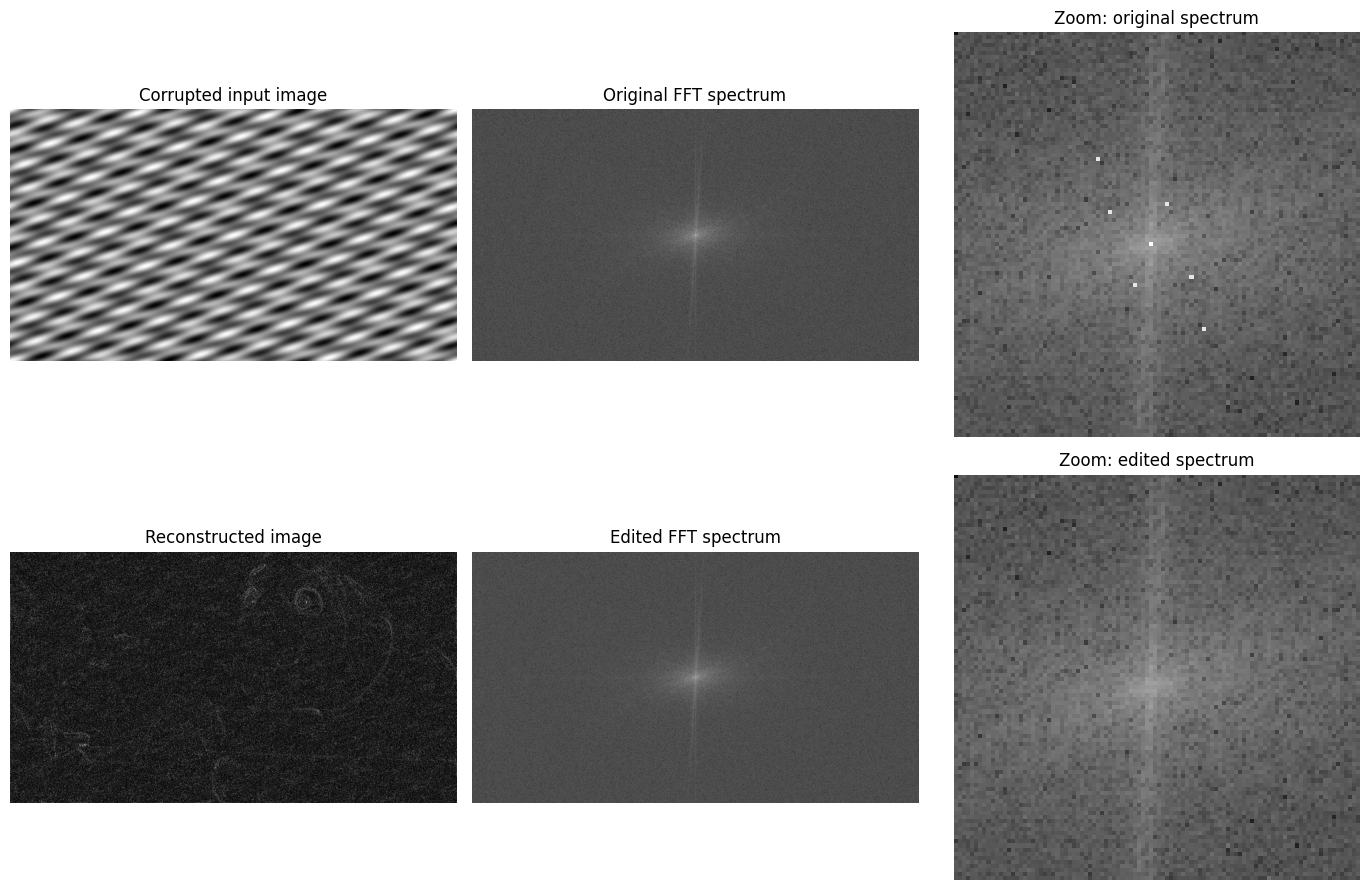

In [601]:



# edit fft_spectrum.png and save the updated spectrum to fft_spectrum_edit.png (you can use any image editing software or even come up with a programmatical solution)

# load edited spectrum if available
if True: #edited_spectrum_path.exists():
    #magnitude_spectrum_edit_norm = cv2.cvtColor(cv2.imread(str(edited_spectrum_path)), cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0
    has_edit = True

    # use the edited spectrum to reconstruct the uncorrupted image
    # Hint: If you used log(abs(F) + 1), remember to invert this transformation correctly.

    magnitude_spectrum_edit = np.exp(magnitude_spectrum_edit_norm * max_val_phase_spec)

    full_spectrum_edit = magnitude_spectrum_edit * np.exp(1j * phase_spectrum)

    rec_img = i_fourier_shift(full_spectrum_edit)

else:  # just a placeholder to not break the plotting in case you fft_spectrum_edit.png does not exist yet
    magnitude_spectrum_edit_norm = np.ones_like(magnitude_spectrum_norm, dtype=np.float32)
    rec_img = np.ones_like(grayscale_img, dtype=np.float32) * 255
    has_edit = False

# plotting
# zoom region
y0, y1 = 200, 300
x0, x1 = 400, 500

fig, axes = plt.subplots(2, 3, figsize=(14, 9))

# original row
axes[0, 0].imshow(grayscale_img, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('Corrupted input image')
axes[0, 0].axis('off')

axes[0, 1].imshow(magnitude_spectrum_norm, cmap='gray', vmin=0, vmax=1)
axes[0, 1].set_title('Original FFT spectrum')
axes[0, 1].axis('off')

axes[0, 2].imshow(magnitude_spectrum_norm[y0:y1, x0:x1], cmap='gray', vmin=0, vmax=1)
axes[0, 2].set_title('Zoom: original spectrum')
axes[0, 2].axis('off')

# edited row
axes[1, 0].imshow(rec_img, cmap='gray')
axes[1, 0].set_title('Reconstructed image' if has_edit else 'Reconstructed image (TODO)')
axes[1, 0].axis('off')

axes[1, 1].imshow(magnitude_spectrum_edit_norm, cmap='gray', vmin=0, vmax=1)
axes[1, 1].set_title('Edited FFT spectrum' if has_edit else 'Edited FFT spectrum (TODO)')
axes[1, 1].axis('off')

axes[1, 2].imshow(magnitude_spectrum_edit_norm[y0:y1, x0:x1], cmap='gray', vmin=0, vmax=1)
axes[1, 2].set_title('Zoom: edited spectrum' if has_edit else 'Zoom: edited spectrum (TODO)')
axes[1, 2].axis('off')

if not has_edit:
    for ax in axes[1]:
        ax.text(0.5, 0.5, 'TODO', color='red', fontsize=18, fontweight='bold',
                ha='center', va='center', transform=ax.transAxes)

fig.tight_layout()
plt.show()


### Question 3.5: Spatial vs Frequency Domain Filtering: *The Convolution Theorem* (1 point)

Now you have applied filters in the spatial domain via convolutions and directly in the spectral domain.

How is the spatial convolution represented in the frequency domain?
What relationship do you observe between these two approaches?

The spatial convolution is equivalent to point wise multiplication in the frequency space. The latter demands less compute but requieres transformation of the image to be filter to the frequency space. 


---
**Important:**
After finishing the exercise, please upload the **executed** notebook and all relevant plots.

### Feedback
Please fill out this section to help us improve the course for next year.

1. How long did it take you to do this assignment?
2. Was it too hard, too easy or appropiate?
3. If you have other comments, don't hesitate to share.

---